<a href="https://colab.research.google.com/github/todnewman/coe_training/blob/master/Keras_VAE_CNN_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Problem

Classify images from the "Fashion MNIST" data set.   Optimize the test accuracy.

## Dataset

This dataset is the Fashion MNIST dataset


The Labels are:  
0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [11]:
import numpy as np
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten,  Conv2D, MaxPooling2D, Activation, BatchNormalization
from keras import backend as K
from keras.callbacks import EarlyStopping
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import TensorBoard,  ModelCheckpoint
from keras.layers import LeakyReLU
from tensorflow.keras import regularizers # Import regularizers
import os
%matplotlib inline
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"

## Gather and Process Fashion MNIST data

1. First, collect the data from Keras (our goal is someday that our organizational data is this easy to get!)
2. Then split into train and test sets.
3. Next we need to process the data into the proper shape for the CNN
4. Then scale the floats to land between 0 and 1.  Often times we use sklearn's MinMaxScaler for this, but in this case we're going for simplicity.
5. Next take the y_train and y_test labels and encode them one-hot.  This will enable the CNN to function.

In [12]:
# Grab the data from the keras repository

mnist_data = fashion_mnist.load_data()
x = mnist_data[0][0]
y = mnist_data[0][1]



In [13]:

print(x.shape)
print(y.shape)
print(type(y))
print(y)
print(np.unique(y))


(60000, 28, 28)
(60000,)
<class 'numpy.ndarray'>
[9 0 0 ... 3 0 5]
[0 1 2 3 4 5 6 7 8 9]


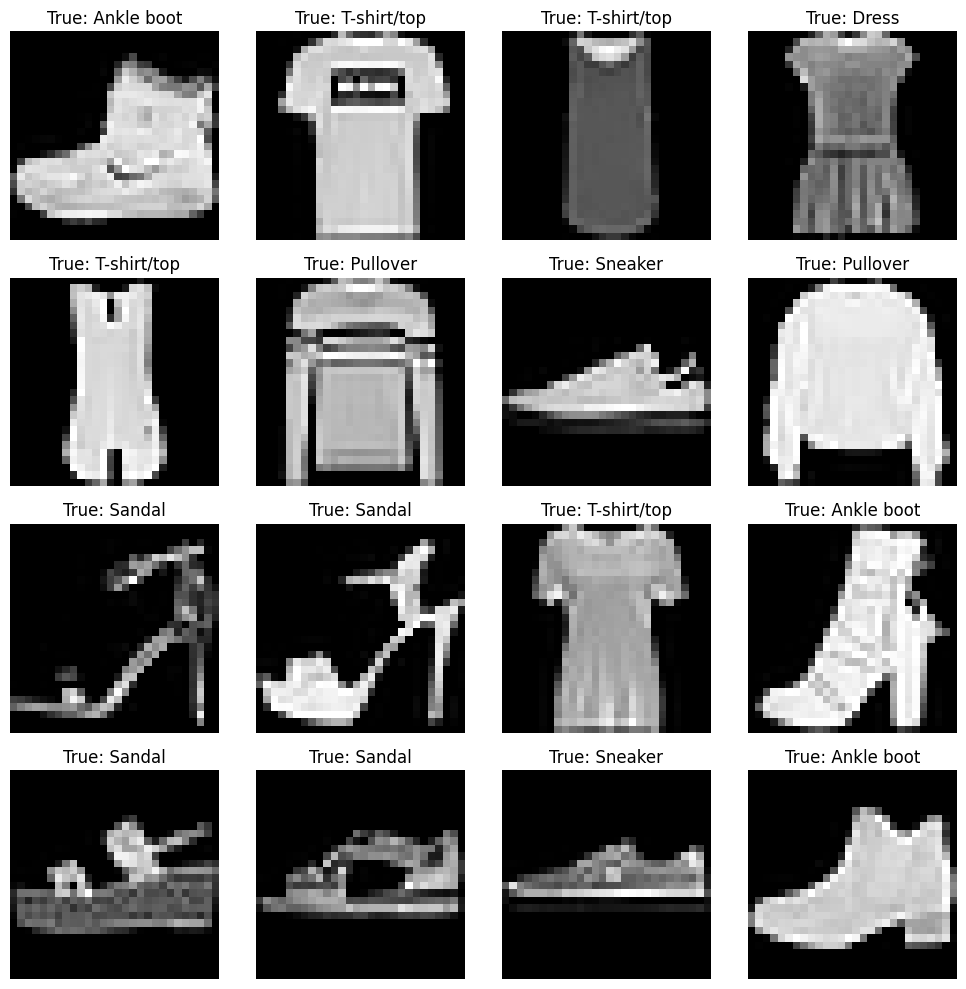


Displaying 16 sample images and their true labels from the original loaded data.


In [14]:


# Define the number of samples to display
num_samples_to_display = 16 # You can change this number

# Define the number of columns for the plot grid
num_cols = 4
num_rows = (num_samples_to_display + num_cols - 1) // num_cols

plt.figure(figsize=(10, num_rows * 2.5)) # Adjust figure size based on number of rows

# Get the original data assuming it was loaded into variables 'x' and 'y'
# using fashion_mnist.load_data() as shown earlier in the notebook.
# Make sure the cells loading the data have been run.

# Define the mapping from integer label to class name for Fashion MNIST
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}


# Loop through the first num_samples_to_display images from the original data
for i in range(num_samples_to_display):
    plt.subplot(num_rows, num_cols, i + 1) # Create a subplot
    plt.imshow(x[i], cmap='gray') # Display the image in grayscale (using original x)

    # Get the true label from the original y and use the dictionary
    true_label = y[i]
    true_label_name = fashion_mnist_labels[true_label]
    plt.title(f"True: {true_label_name}") # Set the title to the true label name
    plt.axis('off') # Turn off axes

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show() # Display the plot

print(f"\nDisplaying {num_samples_to_display} sample images and their true labels from the original loaded data.")

In [28]:
epochs = 10                 # Number of Training Epochs
num_classes = 10            # This is the number of classes in the Fashion MNIST dataset
batch_size = 256            # This parameter can be adjusted
img_rows, img_cols = 28, 28 # Pixel sizes of the Images in the Dataset

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=41)

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)


#  Cast to a 32 bit float and then scale so the value is a float between 0 and 1

x_train = x_train.astype("float32")

x_test = x_test.astype("float32")
x_train /= 255
x_test /= 255

#
# Convert Class Vector to Binary Class Matrices (one-hot encoding).
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test.shape)
print(y_test[10])

#
# Function to decode one-hot encoding later on when we want to evaluate performance.
def decode_one_hot(y):
    y_classes = [np.argmax(yi, axis=None, out=None) for yi in y]
    return y_classes



(19800, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Build the Model

* In this example, we define the below block as a Sequential Model.
* See the excellent [Keras Documentation](https://keras.io/guides/sequential_model/) on Sequential Models for info.
* Many of these parameters can be experimented with.  The documentation will help you understand how much to experiment.

In [39]:
#
# This is what is known as a Tensorflow (Keras) Sequential model
# We will talk at some level about each of these layer types in class.
#
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape))
model.add(Dropout(0.1))
model.add(Activation('tanh'))
model.add(Conv2D(64, kernel_size=(3,3)))
model.add(LeakyReLU(alpha=0.05))
model.add(Dropout(0.1))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Activation('tanh'))
model.add(Flatten())
model.add(Dense(100,kernel_regularizer=regularizers.L1(0.01)))
model.add(Activation('tanh'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

my_callbacks = []

# Optional: Save a copy of the model with the best accuracy during training
#my_callbacks = [ModelCheckpoint('model_out.hdf5', monitor='accuracy', save_best_only=True, save_freq=1)]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Fit and Evaluate the Model

In [40]:
#
# Compile the model so we can fit it. Researching loss functions and optimizers
# might be a good thing to do.
#
epochs=5
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])
hist = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test),
          callbacks=my_callbacks)


score = model.evaluate(x_test, y_test)

#
# Predict on the test data and pass to metrics function
yhat = np.argmax(model.predict(x_test), axis=-1)
y_dec = decode_one_hot(y_test)


print(metrics.classification_report(y_dec, yhat))
print("Testing Loss:", score[0])
print("Testing Accuracy:", score[1])
print("END SUBMISSION BLOCK\n")

model.summary()



Epoch 1/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.1164 - loss: 118.6593 - val_accuracy: 0.1522 - val_loss: 116.8892
Epoch 2/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1196 - loss: 116.3018 - val_accuracy: 0.1701 - val_loss: 114.3388
Epoch 3/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1307 - loss: 113.6828 - val_accuracy: 0.1827 - val_loss: 111.5672
Epoch 4/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1512 - loss: 110.8572 - val_accuracy: 0.1998 - val_loss: 108.6095
Epoch 5/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1613 - loss: 107.8573 - val_accuracy: 0.2312 - val_loss: 105.4962
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2317 - loss: 105.4960
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.40      0.00      0.00      2051
           1       0.00      0.00      0.00      1956
           2       0.25      0.90      0.40      2013
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       921,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,824,580 (10.77 MB)

 Trainable params: 941,526 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,883,054 (7.18 MB)

In [28]:
epochs = 10                 # Number of Training Epochs


In [24]:
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])
hist = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test),
          callbacks=my_callbacks)


score = model.evaluate(x_test, y_test)

#
# Predict on the test data and pass to metrics function
yhat = np.argmax(model.predict(x_test), axis=-1)
y_dec = decode_one_hot(y_test)


print(metrics.classification_report(y_dec, yhat))
print("Testing Loss:", score[0])
print("Testing Accuracy:", score[1])
print("END SUBMISSION BLOCK\n")

model.summary()


score = model.evaluate(x_test, y_test)

#
# Predict on the test data and pass to metrics function
yhat = np.argmax(model.predict(x_test), axis=-1)
y_dec = decode_one_hot(y_test)


print(metrics.classification_report(y_dec, yhat))
print("Testing Loss:", score[0])
print("Testing Accuracy:", score[1])
print("END SUBMISSION BLOCK\n")

model.summary()



not using image augmentation
Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.5646 - loss: 1.4679 - val_accuracy: 0.5914 - val_loss: 1.4680
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5766 - loss: 1.4047 - val_accuracy: 0.6035 - val_loss: 1.4079
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5853 - loss: 1.3500 - val_accuracy: 0.6126 - val_loss: 1.3521
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5970 - loss: 1.2966 - val_accuracy: 0.6219 - val_loss: 1.3008
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6092 - loss: 1.2502 - val_accuracy: 0.6296 - val_loss: 1.2531
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6155 - loss: 1.2108 - val_accuracy: 0.6402 - val_loss: 1.2098
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6165 - loss: 1.1789 - val_accuracy: 0.6491 - val_loss: 1.1703
Epoch 8/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       921,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,824,580 (10.77 MB)

 Trainable params: 941,526 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,883,054 (7.18 MB)

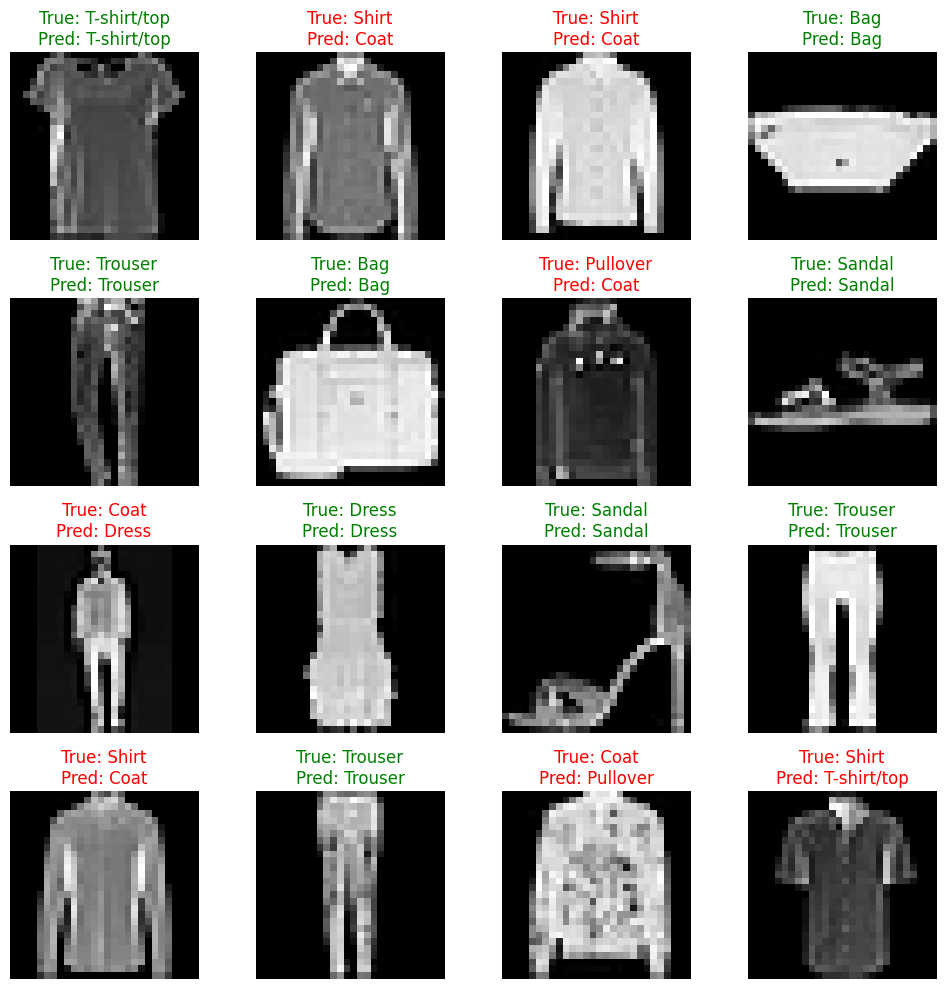


Displaying the first 16 sample images from the test data with true and predicted labels.


In [25]:
# Code to draw the first 16 samples of test data, showing true and predicted labels

import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported if not already
from keras import backend as K # Ensure Keras backend is available

# Define the number of samples to display (first 16)
num_samples_to_display = 16

# Define the number of columns for the plot grid
num_cols = 4
num_rows = (num_samples_to_display + num_cols - 1) // num_cols

# Ensure x_test is in a suitable format for plotting (grayscale, no channel dim)
# This assumes x_test has already been processed into the correct shape for the model
# and scaled to 0-1 float. We will scale back to 0-255 uint8 for displaying.

if K.image_data_format() == "channels_first":
    # Transpose and squeeze to (height, width)
    x_test_plot = np.squeeze(np.transpose(x_test, (0, 2, 3, 1)))
else:
    # Squeeze the last dimension if it's 1
    x_test_plot = np.squeeze(x_test)

# Scale back to 0-255 for displaying
x_test_plot = (x_test_plot * 255).astype("uint8")


plt.figure(figsize=(10, num_rows * 2.5)) # Adjust figure size based on number of rows

# Get the label names mapping
labelNames = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
	"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Ensure y_dec (decoded true labels) and yhat (predicted labels) are available
# y_dec was calculated as: y_dec = decode_one_hot(y_test)
# yhat was calculated as: yhat = np.argmax(model.predict(x_test), axis=-1)
# Make sure these lines have been executed before this plotting code block.

# Loop through the first num_samples_to_display images (indices 0 to 15)
for i in range(num_samples_to_display):
    plt.subplot(num_rows, num_cols, i + 1) # Create a subplot
    plt.imshow(x_test_plot[i], cmap='gray') # Display the image in grayscale

    # Get the true label index (from y_dec) and predicted label index (from yhat)
    true_label_index = y_dec[i]
    predicted_label_index = yhat[i]

    # Get the label names
    true_label_name = labelNames[true_label_index]
    predicted_label_name = labelNames[predicted_label_index]

    # Set the title to show both true and predicted labels
    title_text = f"True: {true_label_name}\nPred: {predicted_label_name}"

    # Optionally, change title color if prediction is wrong
    color = 'green' if true_label_index == predicted_label_index else 'red'

    plt.title(title_text, color=color)
    plt.axis('off') # Turn off axes

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show() # Display the plot

print(f"\nDisplaying the first {num_samples_to_display} sample images from the test data with true and predicted labels.")

In [8]:
print(score)

[1.335008144378662, 0.6419191956520081]


## Plot the accuracy vs. validation accuracy

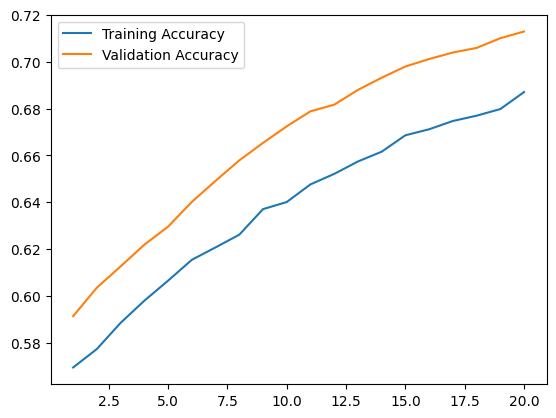

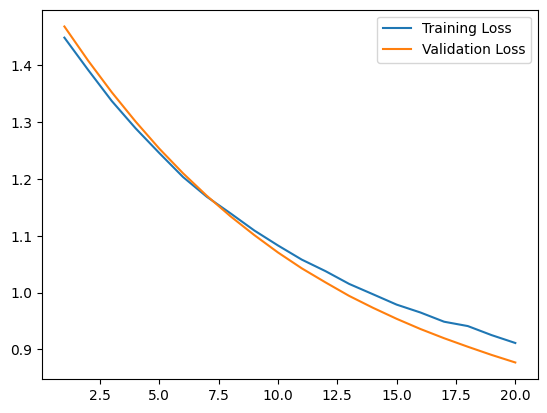

In [27]:
epoch_list = list(range(1, len(hist.history['accuracy']) + 1))
plt.plot(epoch_list, hist.history['accuracy'], epoch_list, hist.history['val_accuracy'])
plt.legend(("Training Accuracy", "Validation Accuracy"))
plt.show()

plt.plot(epoch_list, hist.history['loss'], epoch_list, hist.history['val_loss'])
plt.legend(("Training Loss", "Validation Loss"))
plt.show()